In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("data/cleaned_insurance_analytics.csv")

In [2]:
df.head()

,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure,Claim_ID,Claim_Amount,Claim_Date,Claim_Type,Claim_or_Not,Purchase_Month,Claim_Year,Claim_Month,Tenure_Days
0,1,500001,100000,200,2024-10-02,2025-10-02,2027-10-02,2,NaN,0.0,NaN,NaN,0,10,NaN,NaN,730
1,2,500002,100000,400,2024-04-20,2025-04-20,2029-04-19,4,NaN,0.0,NaN,NaN,0,4,NaN,NaN,1460
2,3,500003,100000,300,2024-07-18,2025-07-18,2028-07-17,3,NaN,0.0,NaN,NaN,0,7,NaN,NaN,1095
3,4,500004,100000,300,2024-07-10,2025-07-10,2028-07-09,3,NaN,0.0,NaN,NaN,0,7,NaN,NaN,1095
4,5,500005,100000,100,2024-11-30,2025-11-30,2026-11-30,1,NaN,0.0,NaN,NaN,0,11,NaN,NaN,365


1. Total Premium Collected in 2024

In [3]:
df["Policy_Purchase_Date"] = pd.to_datetime(df["Policy_Purchase_Date"])

In [6]:
premium_2024 = df[df["Policy_Purchase_Date"].dt.year == 2024]["Premium"].sum()
print(f"Total Premium Collected in 2024: ${premium_2024 :,.0f}")

Total Premium Collected in 2024: $240,254,000


2. Calculate the total claim cost for each year (2025 and 2026) with a monthly breakdown. 

In [11]:
# Convert Claim_Date to datetime
df["Claim_Date"] = pd.to_datetime(df["Claim_Date"])

# Extract Claim Year and Month
df["Claim_Year"] = df["Claim_Date"].dt.year
df["Claim_Month"] = df["Claim_Date"].dt.month

# Keep only rows where a claim exists
claims_df = df[df["Claim_Amount"].notna()]

# Monthly claim cost calculation
claims_summary = (
    claims_df
    .groupby(["Claim_Year", "Claim_Month"], as_index=False)["Claim_Amount"]
    .sum()
)

# Convert to integer
claims_summary["Claim_Year"] = claims_summary["Claim_Year"].astype(int)
claims_summary["Claim_Month"] = claims_summary["Claim_Month"].astype(int)

# Convert claim amount to millions
claims_summary["Claim_Amount_M"] = claims_summary["Claim_Amount"] / 1_000_000

# Format output in $M
claims_summary["Claim_Amount"] = claims_summary["Claim_Amount_M"].apply(
    lambda x: f"${x:,.2f}M"
)

# Final table
final_output = claims_summary[["Claim_Year", "Claim_Month", "Claim_Amount"]]

print(final_output)

    Claim_Year  Claim_Month Claim_Amount
0         2025            1      $33.16M
1         2025            2      $33.47M
2         2025            3      $32.73M
3         2025            4      $32.50M
4         2025            5      $32.40M
5         2025            6      $32.89M
6         2025            7      $33.01M
7         2025            8      $31.91M
8         2025            9      $32.83M
9         2025           10      $32.65M
10        2025           11      $32.95M
11        2025           12      $33.05M
12        2026            1      $52.65M
13        2026            2      $47.32M


In [12]:
df["Claim_or_Not"].sum()

np.int64(49352)

In [17]:
claims_summary["Claim_Year"] = claims_summary["Claim_Year"].astype(int)

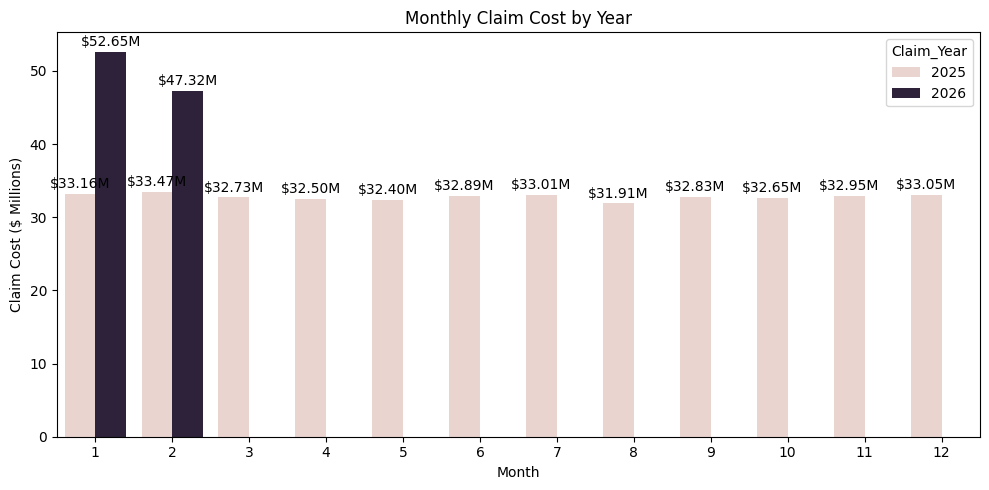

In [21]:


# Ensure year is integer
claims_summary["Claim_Year"] = claims_summary["Claim_Year"].astype(int)

# Create images folder if not exists
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=claims_summary,
    x="Claim_Month",
    y="Claim_Amount_M",
    hue="Claim_Year"
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='$%.2fM',
        label_type='edge',
        padding=2
    )

plt.ylabel("Claim Cost ($ Millions)")
plt.xlabel("Month")
plt.title("Monthly Claim Cost by Year")

plt.tight_layout()

# Save image
plt.savefig("images/monthly_claim_cost.png", dpi=300)

plt.show()

3. Calculate the claim cost to premium ratio for each policy tenure (1, 2, 3, and 4 years).

In [22]:
# Calculate totals by policy tenure
tenure_analysis = (
    df.groupby("Policy_Tenure")
    .agg(
        Total_Premium=("Premium","sum"),
        Total_Claims=("Claim_Amount","sum")
    )
    .reset_index()
)

# Replace NaN claims with 0
tenure_analysis["Total_Claims"] = tenure_analysis["Total_Claims"].fillna(0)

# Calculate ratio
tenure_analysis["Claim_to_Premium_Ratio"] = (
    tenure_analysis["Total_Claims"] /
    tenure_analysis["Total_Premium"]
)

print(tenure_analysis)

   Policy_Tenure  Total_Premium  Total_Claims  Claim_to_Premium_Ratio
0              1       19937600    80450000.0                4.035089
1              2       60021400   117640000.0                1.959968
2              3      120165000   156510000.0                1.302459
3              4       40130000   138920000.0                3.461749


In [23]:
df.groupby("Policy_Tenure")["Claim_or_Not"].sum()

Policy_Tenure
1     8045
2    11764
3    15651
4    13892
Name: Claim_or_Not, dtype: int64

C:\Users\dell\AppData\Local\Temp\ipykernel_5620\4218999280.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


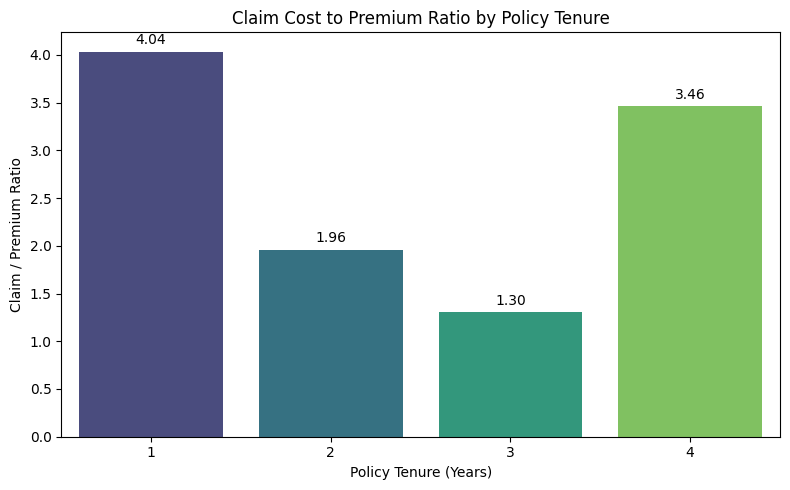

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create images folder
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=tenure_analysis,
    x="Policy_Tenure",
    y="Claim_to_Premium_Ratio",
    palette="viridis"
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Claim Cost to Premium Ratio by Policy Tenure")
plt.xlabel("Policy Tenure (Years)")
plt.ylabel("Claim / Premium Ratio")

plt.tight_layout()

# Save image
plt.savefig("images/claim_premium_ratio_by_tenure.png", dpi=300)

plt.show()

In [25]:
import pandas as pd

# Replace NaN claim values with 0
df["Claim_Amount"] = df["Claim_Amount"].fillna(0)

# Aggregate by purchase month
monthly_analysis = (
    df.groupby("Purchase_Month")
    .agg(
        Total_Premium=("Premium", "sum"),
        Total_Claims=("Claim_Amount", "sum")
    )
    .reset_index()
)

# Calculate ratio
monthly_analysis["Claim_to_Premium_Ratio"] = (
    monthly_analysis["Total_Claims"] /
    monthly_analysis["Total_Premium"]
)

print(monthly_analysis)

    Purchase_Month  Total_Premium  Total_Claims  Claim_to_Premium_Ratio
0                1       20349700    42010000.0                2.064404
1                2       19105100    41440000.0                2.169054
2                3       20311300    41250000.0                2.030889
3                4       19732100    40760000.0                2.065670
4                5       20380200    40500000.0                1.987223
5                6       19773900    41530000.0                2.100243
6                7       20359600    41410000.0                2.033930
7                8       20329100    39990000.0                1.967131
8                9       19664100    40850000.0                2.077390
9               10       20321500    41060000.0                2.020520
10              11       19690600    41340000.0                2.099479
11              12       20236800    41380000.0                2.044790


C:\Users\dell\AppData\Local\Temp\ipykernel_5620\2452790092.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


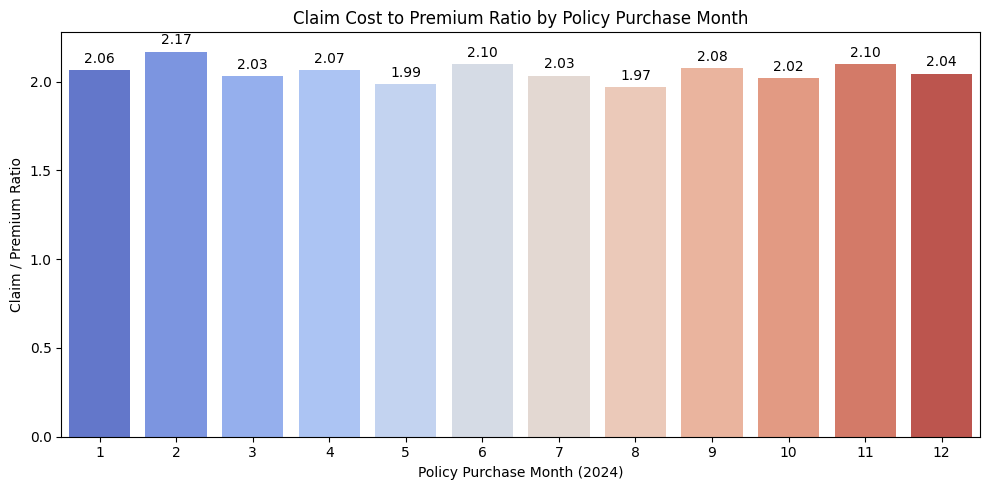

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create folder for images
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=monthly_analysis,
    x="Purchase_Month",
    y="Claim_to_Premium_Ratio",
    palette="coolwarm"
)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Claim Cost to Premium Ratio by Policy Purchase Month")
plt.xlabel("Policy Purchase Month (2024)")
plt.ylabel("Claim / Premium Ratio")

plt.tight_layout()

# Save chart
plt.savefig("images/claim_ratio_by_purchase_month.png", dpi=300)

plt.show()

5. If every vehicle that has not yet made a claim eventually files exactly one claim during the 
remaining policy tenure, estimate the total potential claim liability. 

In [27]:
# Claim amount per vehicle
claim_value = 10000

# Vehicles that never made a claim
no_claim_df = df[df["Claim_or_Not"] == 0]

# Count vehicles
no_claim_count = no_claim_df["Vehicle_ID"].nunique()

# Potential liability
total_liability = no_claim_count * claim_value

print(f"Vehicles with no claims yet: {no_claim_count:,}")
print(f"Estimated Future Claim Liability: ${total_liability:,.0f}")
liability_million = total_liability / 1_000_000

print(f"Estimated Future Claim Liability: ${liability_million:,.2f}M")

Vehicles with no claims yet: 951,006
Estimated Future Claim Liability: $9,510,060,000
Estimated Future Claim Liability: $9,510.06M


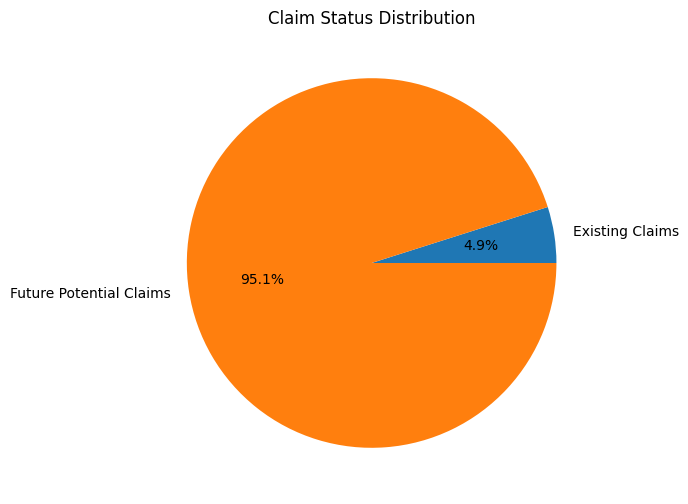

In [28]:
import matplotlib.pyplot as plt

labels = ["Existing Claims", "Future Potential Claims"]
values = [
    df[df["Claim_or_Not"] == 1]["Vehicle_ID"].nunique(),
    no_claim_count
]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Claim Status Distribution")

plt.savefig("images/future_claim_liability.png", dpi=300)

plt.show()

In [31]:
# Convert date columns
df["Policy_Start_Date"] = pd.to_datetime(df["Policy_Start_Date"])
df["Policy_End_Date"] = pd.to_datetime(df["Policy_End_Date"])
df["Policy_Purchase_Date"] = pd.to_datetime(df["Policy_Purchase_Date"])

# Cutoff Date
cutoff_date = pd.to_datetime("2026-02-28")

# Daily Premium
df["Daily_Premium"] = df["Premium"] / df["Tenure_Days"]

# Earned Days
df["Earned_Days"] = (cutoff_date - df["Policy_Start_Date"]).dt.days

df["Earned_Days"] = df["Earned_Days"].clip(lower=0)
df["Earned_Days"] = df[["Earned_Days","Tenure_Days"]].min(axis=1)

# Earned Premium
df["Earned_Premium"] = df["Daily_Premium"] * df["Earned_Days"]

earned_premium_total = df["Earned_Premium"].sum()

print(f"Premium Earned until Feb 28 2026: ${earned_premium_total:,.2f}")

# Remaining Premium
total_premium = df["Premium"].sum()

remaining_premium = total_premium - earned_premium_total

# Monthly Expected Premium
monthly_future_premium = remaining_premium / 46

print(f"Remaining Premium: ${remaining_premium:,.2f}")
print(f"Expected Monthly Premium (Next 46 Months): ${monthly_future_premium:,.2f}")

# Convert to Millions
earned_m = earned_premium_total / 1_000_000
monthly_m = monthly_future_premium / 1_000_000

print(f"Earned Premium: ${earned_m:.2f}M")
print(f"Expected Monthly Premium: ${monthly_m:.2f}M")

Premium Earned until Feb 28 2026: $65,939,401.10
Remaining Premium: $174,314,598.90
Expected Monthly Premium (Next 46 Months): $3,789,447.80
Earned Premium: $65.94M
Expected Monthly Premium: $3.79M


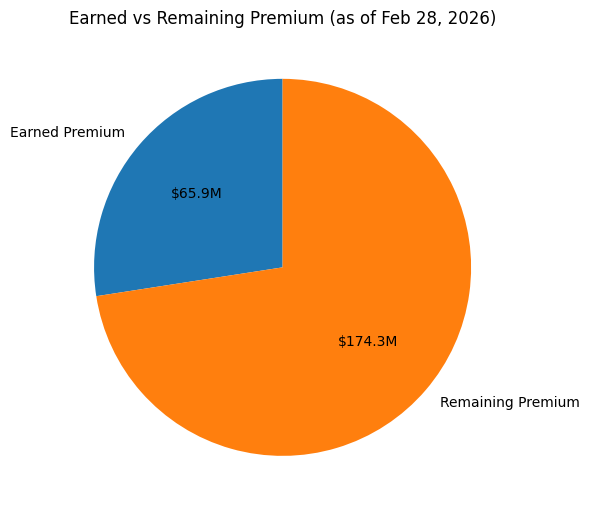

In [32]:
import matplotlib.pyplot as plt
import os

# Create images folder
os.makedirs("images", exist_ok=True)

values = [earned_premium_total, remaining_premium]
labels = ["Earned Premium", "Remaining Premium"]

plt.figure(figsize=(6,6))

plt.pie(
    values,
    labels=labels,
    autopct=lambda p: f"${(p/100*sum(values))/1e6:.1f}M",
    startangle=90
)

plt.title("Earned vs Remaining Premium (as of Feb 28, 2026)")

plt.tight_layout()

plt.savefig("images/earned_vs_remaining_premium.png", dpi=300)

plt.show()

# Part 4. 
Bonus Questions 

Q1. Identify which policy tenure appears most profitable and explain why. 

In [33]:
# Replace NaN claims with 0
df["Claim_Amount"] = df["Claim_Amount"].fillna(0)

# Calculate totals by tenure
tenure_profit = (
    df.groupby("Policy_Tenure")
    .agg(
        Total_Premium=("Premium","sum"),
        Total_Claims=("Claim_Amount","sum")
    )
    .reset_index()
)

# Loss ratio
tenure_profit["Loss_Ratio"] = (
    tenure_profit["Total_Claims"] /
    tenure_profit["Total_Premium"]
)

print(tenure_profit)

   Policy_Tenure  Total_Premium  Total_Claims  Loss_Ratio
0              1       19937600    80450000.0    4.035089
1              2       60021400   117640000.0    1.959968
2              3      120165000   156510000.0    1.302459
3              4       40130000   138920000.0    3.461749


C:\Users\dell\AppData\Local\Temp\ipykernel_5620\33728006.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


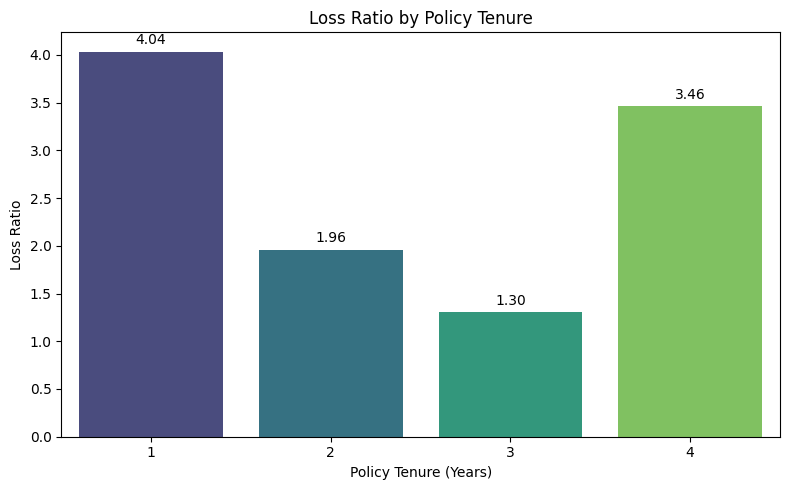

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=tenure_profit,
    x="Policy_Tenure",
    y="Loss_Ratio",
    palette="viridis"
)

# Data labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Loss Ratio by Policy Tenure")
plt.xlabel("Policy Tenure (Years)")
plt.ylabel("Loss Ratio")

plt.tight_layout()

plt.savefig("images/profitability_by_tenure.png", dpi=300)

plt.show()

The 3-year policy tenure is the most profitable because it achieves the best balance between premium revenue and claim exposure.

Shorter policies, such as 1-year policies, generate lower total premiums while still experiencing claims, which results in a higher loss ratio. On the other hand, 4-year policies remain active for a longer period, increasing the probability of multiple claims, which also raises the loss ratio.

In contrast, 3-year policies collect relatively higher premiums while maintaining a moderate claim frequency, leading to the lowest claim-to-premium ratio (1.30) among all tenures. This makes the 3-year tenure the most financially efficient option for the insurer.

In [39]:
# Recalculate claims summary from raw data
claims_summary = (
    df[df["Claim_Amount"].notna()]
    .groupby(["Claim_Year","Claim_Month"], as_index=False)["Claim_Amount"]
    .sum()
)

# Convert to millions
claims_summary["Claim_Amount_M"] = claims_summary["Claim_Amount"] / 1_000_000

print(claims_summary.head())

   Claim_Year  Claim_Month  Claim_Amount  Claim_Amount_M
0      2025.0          1.0    33160000.0           33.16
1      2025.0          2.0    33470000.0           33.47
2      2025.0          3.0    32730000.0           32.73
3      2025.0          4.0    32500000.0           32.50
4      2025.0          5.0    32400000.0           32.40


Q2. Build a simple dashboard or visualization showing claim trends by month. 

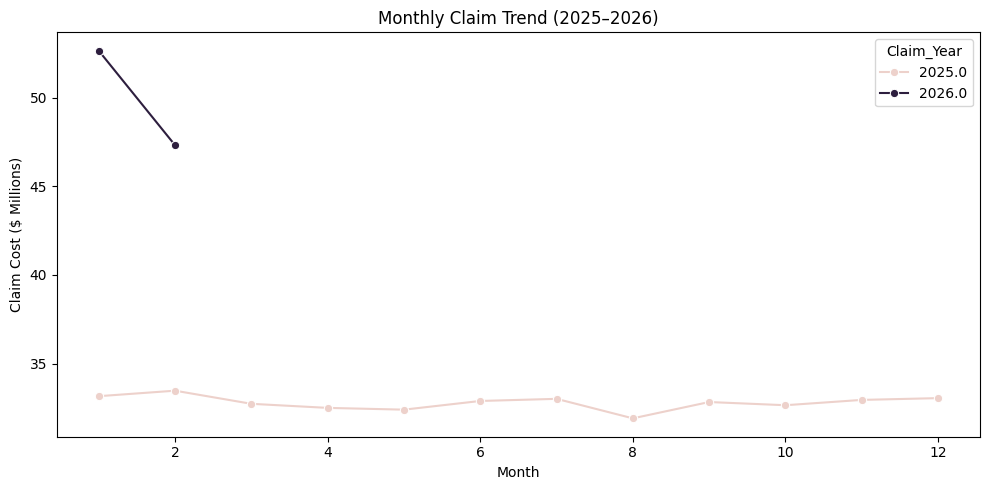

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=claims_summary,
    x="Claim_Month",
    y="Claim_Amount_M",
    hue="Claim_Year",
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Claim Cost ($ Millions)")
plt.title("Monthly Claim Trend (2025–2026)")

plt.tight_layout()

plt.savefig("images/claim_trend_by_month.png", dpi=300)

plt.show()

Claim costs remain relatively stable throughout 2025, indicating a consistent pattern of claims due to evenly distributed policy sales. In 2026, claims appear only in January and February, with higher costs compared to individual months in 2025 because 4-year tenure policies generate additional claims during this period.

In [38]:
print(claims_summary.head())
print(claims_summary.dtypes)
print(claims_summary.shape)

   Claim_Year  Claim_Month  Claim_Amount  Claim_Amount_M
0        2025            1           NaN             NaN
1        2025            2           NaN             NaN
2        2025            3           NaN             NaN
3        2025            4           NaN             NaN
4        2025            5           NaN             NaN
Claim_Year          int64
Claim_Month         int64
Claim_Amount      float64
Claim_Amount_M    float64
dtype: object
(14, 4)


Q3. Estimate the loss ratio (Claims ÷ Premium) for the portfolio. 

In [42]:
# Replace NaN claims with 0
df["Claim_Amount"] = df["Claim_Amount"].fillna(0)

# Calculate totals
total_claims = df["Claim_Amount"].sum()
total_premium = df["Premium"].sum()

# Loss ratio
portfolio_loss_ratio = total_claims / total_premium

premium_m = total_premium / 1_000_000
claims_m = total_claims / 1_000_000

print(f"Total Premium: ${premium_m:.2f}M")
print(f"Total Claims: ${claims_m:.2f}M")
print(f"Portfolio Loss Ratio: {portfolio_loss_ratio:.2f}")

Total Premium: $240.25M
Total Claims: $493.52M
Portfolio Loss Ratio: 2.05


The portfolio shows a loss ratio of 2.05, meaning total claims are more than double the premium collected. This indicates that the portfolio is currently unprofitable, as claim payouts significantly exceed premium revenue.

4. If claim frequency increases by 5% annually, estimate the impact on future profitability.

In [43]:
# Replace NaN claims with 0
df["Claim_Amount"] = df["Claim_Amount"].fillna(0)

# Current totals
total_premium = df["Premium"].sum()
total_claims = df["Claim_Amount"].sum()

# Current loss ratio
current_loss_ratio = total_claims / total_premium

print(f"Current Loss Ratio: {current_loss_ratio:.2f}")

Current Loss Ratio: 2.05


In [44]:
# Increase claims by 5%
future_claims = total_claims * 1.05

# New loss ratio
future_loss_ratio = future_claims / total_premium

print(f"Future Loss Ratio after 5% increase in claims: {future_loss_ratio:.2f}")

Future Loss Ratio after 5% increase in claims: 2.16


In [46]:
loss_ratio_change = future_loss_ratio - current_loss_ratio

print(f"Current Loss Ratio: {current_loss_ratio:.2f}")
print(f"Future Loss Ratio (after 5% claim increase): {future_loss_ratio:.2f}")
print(f"Increase in Loss Ratio: {loss_ratio_change:.2f}")

Current Loss Ratio: 2.05
Future Loss Ratio (after 5% claim increase): 2.16
Increase in Loss Ratio: 0.10


A 5% increase in claim frequency raises the portfolio loss ratio from 2.05 to 2.16, indicating that claims consume an even larger portion of premium revenue. This suggests a decline in overall profitability.

Recommendation

The insurer should consider adjusting premium pricing, strengthening risk assessment, or improving claim management practices to mitigate the financial impact of increasing claim frequency.